# 22 · Del MILP a una política laminar

## Pregunta de esta iteración

La sesión con Francisco dejó dos ideas distintas. Este cuaderno evita
mezclarlas:

1. **Oráculo de muestreo.** Formular la elección de la siguiente muestra como
   un MILP, observar el conteo y volver a optimizar bajo el posterior.
2. **Estructura laminar.** Separar tres preguntas: inferencia exacta,
   calidad de la mejor política restringida y costo de encontrarla.

El resultado más limpio que buscamos no es todavía “lo laminar aproxima al
óptimo”. Es más básico y más sólido: **un historial laminar ramificado se
descompone en átomos disjuntos con conteos conocidos, por lo que su posterior
se calcula exactamente en tiempo polinomial**. Después medimos —sin convertir
un barrido finito en teorema— cuánto welfare retienen varias clases laminares.

### Qué significa cada etiqueta

- **VERIFICADO:** identidad comprobada contra fuerza bruta o contra el solver
  de referencia en el régimen donde ambos corren.
- **EVIDENCIA:** resultado reproducible del barrido indicado; no es una cota
  universal.
- **CONJETURA:** blanco de prueba o de búsqueda de contraejemplos.

Todas las semillas, distribuciones y tamaños aparecen en las celdas. Los
`assert` comprueban invariantes matemáticos; no se usan para imponer que un
experimento “salga bonito”.

## Hilo conductor

Organizar las pruebas como familias anidadas pierde poco welfare frente a la
libertad total y, a cambio, vuelve exacta la inferencia; y donde la inferencia
es exacta, las mejoras de política dejan de ser heurísticas y admiten
garantías. Ese es el hilo que une las dos partes del cuaderno: la Parte I
construye el selector exacto que arranca el ciclo de decisión y la Parte II
aísla qué compra y qué cuesta la estructura laminar.

La primera mitad de esa afirmación es de calidad. El óptimo sin restricción
$V^*$ puede elegir en cada paso cualquiera de los $\sum_{g\le G}\binom ng$
pools y traslaparlos a voluntad; una familia laminar —dos pools o son ajenos o
uno contiene al otro— forma un árbol con $O(n)$ pools. El barrido de la
sección 5 ($n=5$, $B=3$, $G=3$, 45 instancias por generador) indica que la
restricción cuesta poco: la peor razón observada es 0.943 para path-laminar y
0.908 para el portafolio de bibliotecas fijas, con medianas entre 0.956 y
0.994. Es EVIDENCIA de barrido, no cota; la instancia peor (razón 0.9433)
alimenta la búsqueda adversaria de la Conjetura C.

La segunda mitad es la razón estructural de que la restricción convenga. Con
pools traslapados el posterior exacto exige enumerar $2^n$ perfiles y en la
práctica se aproxima con el producto de marginales, que se equivoca: en la
sección 2, el valor exacto del pool ya observado es 0.000000 y el producto de
marginales le asigna 1.022492. En un historial laminar la cuenta se vuelve una
resta —si $\{0,1,2,3\}$ dio conteo 1 y $\{0,1\}$ dio 1, el residuo $\{2,3\}$
tiene exactamente 0— y la sección 3 lo generaliza: los átomos residuales
parten la población, el posterior factoriza entre átomos y las marginales
salen de mensajes Poisson-binomial en $O(n^2)$, verificado contra fuerza bruta
y corrido en 0.014 s para $n=800$.

La exactitud cambia el estatus del greedy. La garantía rollout $\ge$ greedy
supone esperanzas exactas; el notebook 21 §7 mostró que, con la aproximación
de independencia, el error se come el premio del lookahead y la mejora
prometida no se materializa. Dentro de una biblioteca laminar las esperanzas
son exactas, la garantía se cumple de verdad y la sección 7 la mide: el
rollout mejora al greedy en 77–83% de las instancias y queda a menos de medio
punto del óptimo de su biblioteca (0.938 contra 0.942 sobre $V^*$ en el
generador moderado). Ésa es la Proposición B, y el Lema A de inferencia es lo
que la hace demostrable.

El encadenamiento de los tres entregables de la sección 8 es la meta del
programa: si el Lema A da inferencia exacta, la Proposición B da rollout
$\approx$ óptimo de $\mathcal L$, y la Conjetura C da
$V^{\mathcal L}\ge\alpha V^*$, entonces el greedy laminar es una política
simple con garantía frente al óptimo verdadero. El MILP por escenarios no
compite con ese programa: es el selector miope exacto que lo arranca,
siguiendo el ciclo partículas → pool → conteo → átomos → rollout.

Queda un marco para después. Una familia laminar es el caso árbol de una
escalera más general: la inferencia exacta cuesta tiempo exponencial en el
treewidth del grafo de restricciones de conteo, no en $n$. La aproximación de
independencia vive en el extremo de ancho cero, lo laminar en el caso árbol, y
entre éste y la libertad total hay clases de ancho acotado con costo
$\exp(w)\,\mathrm{poly}(n)$. La pregunta natural —cuánto welfare compra cada
unidad de ancho— reutilizaría el barrido de la sección 5; este cuaderno no la
explora, pero responde de antemano por qué se estudia lo laminar: es la clase
donde la distribución verdadera es de árbol, no una restricción de
conveniencia.

In [1]:
import sys
from pathlib import Path

ROOT = next((d for d in (Path.cwd(), *Path.cwd().parents)
             if (d / 'augmented').is_dir()), None)
if ROOT is None:
    raise RuntimeError('No se encontró la raíz que contiene augmented/')
sys.path.insert(0, str(ROOT))

import math, time
from functools import lru_cache

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse import coo_matrix

from augmented.core import (all_pools, test_result, bin_of,
                            indices_from_mask, mask_from_indices)
from augmented.solver import solve_optimal_dapts
from augmented.bayesian import bayesian_update_by_counting

AZUL, GRIS, AMBAR, TINTA, VERDE = '#2563eb', '#6b7280', '#d97706', '#374151', '#059669'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'grid.linewidth': 0.5, 'font.size': 10})
print('setup listo')

setup listo


## 0. Auditoría del primer borrador

El primer notebook 22 tenía buenas piezas, pero la conclusión iba más rápido
que la evidencia.

| Pieza original | Diagnóstico | Decisión aquí |
|---|---|---|
| Set packing para el estático no traslapado | Correcto, pero resuelve una referencia estática y no la transición adaptativa | Se conserva como antecedente, no como resultado central |
| Selector Mosek del pool miope | Útil y rápido, pero es **entero cónico**, no MILP; además depende de licencia | Se reemplaza por un MILP lineal sobre escenarios ponderados |
| “Óptimo laminar” | El código imponía laminaridad sólo en cada camino realizado | Se renombra $V^{\mathrm{path\text{-}lam}}$ y se distingue de una biblioteca global fija |
| “Es más fácil de encontrar” | Una instancia por $n$ y estados distintos no bastan para una afirmación de complejidad | Se reportan estados, acciones Bellman, tiempo y réplicas pareadas |
| Greedy miope + poda laminar | Buen control negativo | Se mantiene, pero el candidato positivo pasa a ser rollout dentro de una jerarquía fija |

La distinción decisiva es ésta:

$$
V^{\mathcal L}\;\le\;V^{\mathrm{path\text{-}lam}}\;\le\;V^*,
$$

donde $\mathcal L$ es una biblioteca laminar fijada antes de ver respuestas,
$V^{\mathrm{path\text{-}lam}}$ permite que la familia cambie entre ramas
siempre que cada camino sea laminar, y $V^*$ no restringe los pools.

# Parte I · Un MILP que elige la muestra y transiciona a la respuesta

## 1. Formulación por escenarios del posterior

Supongamos que el posterior actual está representado por perfiles
$z^s\in\{0,1\}^n$ con pesos $\pi_s$; $z_i^s=1$ significa activo. Elegimos
$x_i\in\{0,1\}$ y $1\le\sum_i x_i\le G$. Para cada escenario:

- $y_s=1$ si la muestra sale limpia: $\sum_i z_i^s x_i=0$;
- $w_{is}=x_i y_s$ linealiza quién se acredita en ese escenario.

El objetivo miope exacto bajo la distribución empírica es

$$
\max \sum_s\pi_s\sum_i u_i w_{is}.
$$

Las restricciones $y_s+x_i\le1$ para cada $i$ activo en $s$ y
$y_s+\sum_{i:z_i^s=1}x_i\ge1$ fijan el indicador de muestra limpia. Las tres
desigualdades de McCormick fijan $w_{is}=x_i y_s$. Sólo $x$ necesita ser
entero: dado $x$, las restricciones fuerzan $y$ y $w$ a cero o uno.

Esto sí es un **MILP lineal**. A diferencia de multiplicar marginales, acepta
escenarios correlacionados obtenidos después de conteos previos.

In [2]:
def exact_prior_scenarios(p):
    '''Todos los perfiles Bernoulli independientes y sus probabilidades.'''
    p = np.asarray(p, dtype=float)
    n = len(p)
    ids = np.arange(1 << n, dtype=np.uint64)[:, None]
    bits = np.arange(n, dtype=np.uint64)[None, :]
    Z = ((ids >> bits) & 1).astype(np.int8)
    weights = np.prod(np.where(Z == 1, p, 1 - p), axis=1)
    return Z, weights / weights.sum()


def score_pool_scenarios(pool, Z, weights, u, cleared=0):
    '''Welfare inmediato exacto/empírico del pool bajo escenarios ponderados.'''
    n = Z.shape[1]
    idx = indices_from_mask(pool, n)
    if not idx:
        return 0.0
    clean = (Z[:, idx].sum(axis=1) == 0)
    gain = sum(u[i] for i in idx if not ((cleared >> i) & 1))
    return float(weights[clean].sum() * gain)


def brute_best_pool_scenarios(Z, weights, u, G, cleared=0):
    n = Z.shape[1]
    vals = [(score_pool_scenarios(t, Z, weights, u, cleared), t)
            for t in all_pools(n, G, include_empty=False)]
    return max(vals)


def milp_best_pool_scenarios(Z, weights, u, G, cleared=0, time_limit=30):
    '''MILP del pool miope sobre una distribución discreta del posterior.'''
    Z = np.asarray(Z, dtype=np.int8)
    weights = np.asarray(weights, dtype=float)
    weights = weights / weights.sum()
    S, n = Z.shape
    if len(u) != n or not (1 <= G <= n):
        raise ValueError('dimensiones incompatibles o G fuera de rango')

    # Variables: x_i, y_s y w_{s,i}.
    off_y, off_w = n, n + S
    ix = lambda i: i
    iy = lambda s: off_y + s
    iw = lambda s, i: off_w + s * n + i
    nvars = n + S + S * n

    c = np.zeros(nvars)
    reward_u = np.array([0.0 if ((cleared >> i) & 1) else u[i]
                         for i in range(n)])
    for s in range(S):
        for i in range(n):
            c[iw(s, i)] = -weights[s] * reward_u[i]

    rows, cols, data, lbs, ubs = [], [], [], [], []

    def add(coeffs, lb=-np.inf, ub=np.inf):
        row = len(lbs)
        for col, val in coeffs.items():
            rows.append(row); cols.append(col); data.append(val)
        lbs.append(lb); ubs.append(ub)

    add({ix(i): 1.0 for i in range(n)}, lb=1.0, ub=float(G))

    for s in range(S):
        infected = np.flatnonzero(Z[s])
        # y_s=0 si se selecciona al menos un activo del escenario.
        for i in infected:
            add({iy(s): 1.0, ix(int(i)): 1.0}, ub=1.0)
        # y_s=1 si no se selecciona ningún activo.
        force_clean = {iy(s): 1.0}
        force_clean.update({ix(int(i)): 1.0 for i in infected})
        add(force_clean, lb=1.0)

        # Envolvente exacta de w_{s,i}=x_i*y_s para x_i,y_s binarios.
        for i in range(n):
            add({iw(s, i): 1.0, ix(i): -1.0}, ub=0.0)
            add({iw(s, i): 1.0, iy(s): -1.0}, ub=0.0)
            add({iw(s, i): 1.0, ix(i): -1.0, iy(s): -1.0}, lb=-1.0)

    A = coo_matrix((data, (rows, cols)), shape=(len(lbs), nvars)).tocsr()
    integrality = np.zeros(nvars, dtype=int)
    integrality[:n] = 1
    res = milp(c=c, integrality=integrality, bounds=Bounds(0.0, 1.0),
               constraints=LinearConstraint(A, np.array(lbs), np.array(ubs)),
               options={'time_limit': float(time_limit)})
    if not res.success:
        raise RuntimeError(f'MILP no resolvió: {res.message}')
    pool = mask_from_indices(np.flatnonzero(res.x[:n] > 0.5).tolist())
    return score_pool_scenarios(pool, Z, weights, u, cleared), pool, res


def condition_on_count(Z, weights, pool, observed_r):
    idx = indices_from_mask(pool, Z.shape[1])
    keep = (Z[:, idx].sum(axis=1) == observed_r)
    if not np.any(keep) or weights[keep].sum() <= 0:
        raise ValueError('respuesta sin soporte en los escenarios')
    new_w = weights[keep] / weights[keep].sum()
    return Z[keep], new_w


print('MILP por escenarios listo')

MILP por escenarios listo


In [3]:
# VERIFICADO: el MILP coincide con enumerar todos los pools en un prior exacto.
p1 = np.array([0.20, 0.35, 0.55, 0.15, 0.60, 0.40, 0.25])
u1 = np.array([1.0, 2.5, 1.2, 3.0, 0.8, 2.0, 1.7])
G1 = 3
Z1, w1 = exact_prior_scenarios(p1)

t0 = time.perf_counter()
v_bf, pool_bf = brute_best_pool_scenarios(Z1, w1, u1, G1)
t_bf = time.perf_counter() - t0
t0 = time.perf_counter()
v_milp, pool_milp, _ = milp_best_pool_scenarios(Z1, w1, u1, G1)
t_milp = time.perf_counter() - t0

assert abs(v_milp - v_bf) < 1e-8
print('prior exacto (2^7 escenarios)')
print(f'  fuerza bruta: valor={v_bf:.6f}, pool={indices_from_mask(pool_bf, len(p1))}, {t_bf:.3f}s')
print(f'  MILP         : valor={v_milp:.6f}, pool={indices_from_mask(pool_milp, len(p1))}, {t_milp:.3f}s')

prior exacto (2^7 escenarios)
  fuerza bruta: valor=3.038750, pool=[1, 3], 0.000s
  MILP         : valor=3.038750, pool=[1, 3], 0.093s


## 2. La transición no se escribe a mano: se condicionan escenarios

Después de observar $R=r$, conservamos los escenarios que satisfacen
$\sum_{i\in t}z_i^s=r$, renormalizamos sus pesos y resolvemos el mismo MILP.
Ésta es la conexión concreta “tomar muestra → recibir respuesta → tomar la
siguiente muestra”. En el ejemplo siguiente el posterior ya es correlacionado;
el objetivo no usa el producto de marginales.

In [4]:
r_obs = 1
Z_post, w_post = condition_on_count(Z1, w1, pool_milp, r_obs)
post_marg = w_post @ Z_post
v2_bf, pool2_bf = brute_best_pool_scenarios(Z_post, w_post, u1, G1)
v2_milp, pool2_milp, _ = milp_best_pool_scenarios(Z_post, w_post, u1, G1)
assert abs(v2_milp - v2_bf) < 1e-8

idx2 = indices_from_mask(pool2_milp, len(p1))
idx_corr = indices_from_mask(pool_milp, len(p1))
exact_corr = score_pool_scenarios(pool_milp, Z_post, w_post, u1)
ind_corr = math.prod(1 - post_marg[i] for i in idx_corr) * sum(u1[i] for i in idx_corr)
print(f'primera muestra {indices_from_mask(pool_milp, len(p1))}, respuesta observada R={r_obs}')
print(f'escenarios: {len(Z1)} -> {len(Z_post)}; masa posterior renormalizada={w_post.sum():.1f}')
print(f'siguiente MILP: pool={idx2}, valor posterior exacto={v2_milp:.6f}')
print(f'control de correlación sobre el pool observado: exacto={exact_corr:.6f}, '
      f'producto de marginales={ind_corr:.6f}')
print('marginales posteriores:', np.round(post_marg, 3).tolist())

primera muestra [1, 3], respuesta observada R=1
escenarios: 128 -> 64; masa posterior renormalizada=1.0
siguiente MILP: pool=[3, 6], valor posterior exacto=2.654905
control de correlación sobre el pool observado: exacto=0.000000, producto de marginales=1.022492
marginales posteriores: [0.2, 0.753, 0.55, 0.247, 0.6, 0.4, 0.25]


In [5]:
# Escala aproximada: partículas en lugar de los 2^n perfiles.
rng = np.random.default_rng(2207)
n_large, S_large, G_large = 40, 100, 5
p_large = rng.uniform(0.08, 0.65, n_large)
u_large = rng.uniform(0.5, 4.0, n_large)
Z_large = (rng.random((S_large, n_large)) < p_large).astype(np.int8)
w_large = np.full(S_large, 1 / S_large)
t0 = time.perf_counter()
v_large, pool_large, res_large = milp_best_pool_scenarios(
    Z_large, w_large, u_large, G_large, time_limit=30)
dt_large = time.perf_counter() - t0
print(f'n={n_large}, S={S_large}, G={G_large}: pool={indices_from_mask(pool_large, n_large)}')
print(f'valor empírico={v_large:.4f}, tiempo={dt_large:.2f}s, gap MILP reportado={res_large.mip_gap:.2e}')

n=40, S=100, G=5: pool=[3, 19, 24, 33, 36]
valor empírico=8.4220, tiempo=4.30s, gap MILP reportado=0.00e+00


**Lectura.** El MILP por escenarios es un oráculo de decisión, no una
solución completa del árbol dinámico. Su promesa es modular: acepta partículas
de Gibbs/SMC, respeta la correlación y se vuelve a llamar tras cada respuesta.
Sus dos riesgos medibles son el tamaño $O(nS)$ de la formulación y el error de
Monte Carlo. El siguiente experimento natural es comparar su pool contra el
óptimo exacto para $n\le 12$ mientras se barre $S$.

# Parte II · Lo laminar

## 3. Resultado algorítmico aislable: inferencia exacta en un bosque laminar

Una familia $\mathcal F$ es laminar si para cualesquiera $A,B\in\mathcal F$,
$A\cap B\in\{\varnothing,A,B\}$. El notebook 21 resolvió una **cadena** de
pools anidados mediante anillos. La misma idea se extiende a ramificaciones.

Para cada nodo $A$, sean sus hijos los subconjuntos máximos de $A$ presentes
en $\mathcal F$. Definimos el átomo residual

$$D_A=A\setminus\bigcup_{C\in\mathrm{hijos}(A)} C,$$

con conteo conocido $c(D_A)=c(A)-\sum_C c(C)$. Los átomos son disjuntos y las
restricciones originales son equivalentes a fijar un conteo en cada átomo.
Bajo priors Bernoulli independientes, el posterior factoriza entre átomos.

La fase probabilística usa mensajes forward/backward de Poisson-binomial. Para
un átomo de tamaño $m$ y conteo $c$, todas sus marginales se obtienen en
$O(mc)$ tiempo y memoria; **dado el mapa padre-hijos**, sobre el bosque el peor
caso es $O(n^2)$ y no $O(2^n)$. El parser pedagógico de abajo descubre ese mapa
con búsquedas cúbicas en el número de pools; una implementación de producción
debe recibir la jerarquía o construirla con un índice de inclusión.

In [6]:
def _conditional_bernoulli_marginals(probs, count):
    '''Marginales de Bernoullis independientes condicionadas a suma=count.'''
    probs = np.asarray(probs, dtype=float)
    m = len(probs)
    if not (0 <= count <= m):
        raise ValueError('conteo fuera de rango')
    # Mensajes truncados a count: basta para P(S=count) y P(S_-i=count-1).
    fw = np.zeros((m + 1, count + 1)); fw[0, 0] = 1.0
    for i, pr in enumerate(probs):
        fw[i + 1] += fw[i] * (1 - pr)
        if count:
            fw[i + 1, 1:] += fw[i, :-1] * pr
    bw = np.zeros((m + 1, count + 1)); bw[m, 0] = 1.0
    for i in range(m - 1, -1, -1):
        pr = probs[i]
        bw[i] += bw[i + 1] * (1 - pr)
        if count:
            bw[i, 1:] += bw[i + 1, :-1] * pr
    denom = fw[m, count]
    if denom <= 1e-300:
        raise ValueError('el evento condicionado tiene probabilidad numérica cero')
    marg = np.zeros(m)
    if count == 0:
        return marg
    target = count - 1
    for i, pr in enumerate(probs):
        ways = sum(fw[i, a] * bw[i + 1, target - a]
                   for a in range(target + 1)
                   if a < fw.shape[1] and target - a < bw.shape[1])
        marg[i] = pr * ways / denom
    return marg


def laminar_atoms(history, n):
    '''Devuelve (atom_mask, atom_count, parent_mask) de un historial laminar.'''
    counts = {}
    for mask, count in history:
        mask, count = int(mask), int(count)
        if mask <= 0 or mask >= (1 << n):
            raise ValueError('pool vacío o fuera del universo')
        if mask in counts and counts[mask] != count:
            raise ValueError('el mismo pool tiene conteos incompatibles')
        counts[mask] = count
    masks = list(counts)
    for i, a in enumerate(masks):
        if not (0 <= counts[a] <= a.bit_count()):
            raise ValueError('conteo fuera del tamaño del pool')
        for b in masks[i + 1:]:
            inter = a & b
            if inter and inter != a and inter != b:
                raise ValueError('el historial no es laminar')

    atoms = []
    for parent in masks:
        strict_subsets = [s for s in masks if s != parent and (s & parent) == s]
        children = [s for s in strict_subsets
                    if not any(s != mid and (s & mid) == s and
                               mid != parent and (mid & parent) == mid
                               for mid in strict_subsets)]
        covered = 0
        for child in children:
            covered |= child
        atom = parent & ~covered
        atom_count = counts[parent] - sum(counts[c] for c in children)
        if atom_count < 0 or atom_count > atom.bit_count():
            raise ValueError('conteos incompatibles en padre e hijos')
        if atom:
            atoms.append((atom, atom_count, parent))
        elif atom_count != 0:
            raise ValueError('átomo vacío con conteo positivo')
    return atoms


def laminar_forest_marginals(p, history):
    '''Posterior marginal exacto para una familia laminar de conteos.'''
    n = len(p)
    marg = np.asarray(p, dtype=float).copy()
    atoms = laminar_atoms(history, n)
    seen = 0
    for atom, count, _ in atoms:
        if seen & atom:
            raise AssertionError('los átomos deben ser disjuntos')
        seen |= atom
        idx = indices_from_mask(atom, n)
        marg[idx] = _conditional_bernoulli_marginals(marg[idx], count)
    return marg, atoms


print('inferencia para bosque laminar lista')

inferencia para bosque laminar lista


In [7]:
# VERIFICADO contra enumeración exacta: familia ramificada, no sólo cadena.
rng = np.random.default_rng(21)
n_inf = 8
p_inf = rng.uniform(0.18, 0.72, n_inf).tolist()
history_inf = (
    (mask_from_indices(range(8)), 4),
    (mask_from_indices([0, 1, 2, 3]), 1),
    (mask_from_indices([0, 1]), 1),
    (mask_from_indices([4, 5]), 2),
)
brute_inf = bayesian_update_by_counting(p_inf, history_inf, n_inf)
lam_inf, atoms_inf = laminar_forest_marginals(p_inf, history_inf)
err_inf = float(np.max(np.abs(np.asarray(brute_inf) - lam_inf)))
assert err_inf < 1e-10
assert all(abs(sum(lam_inf[i] for i in indices_from_mask(a, n_inf)) - c) < 1e-9
           for a, c, _ in atoms_inf)
print(f'max |bosque laminar - fuerza bruta| = {err_inf:.2e}')
print('átomos (miembros, conteo):')
for atom, count, parent in atoms_inf:
    print(f'  {indices_from_mask(atom, n_inf)} -> {count}   (residuo de {indices_from_mask(parent, n_inf)})')
print('posterior:', np.round(lam_inf, 3).tolist())

max |bosque laminar - fuerza bruta| = 0.00e+00
átomos (miembros, conteo):
  [6, 7] -> 1   (residuo de [0, 1, 2, 3, 4, 5, 6, 7])
  [2, 3] -> 0   (residuo de [0, 1, 2, 3])
  [0, 1] -> 1   (residuo de [0, 1])
  [4, 5] -> 2   (residuo de [4, 5])
posterior: [0.595, 0.405, 0.0, 0.0, 1.0, 1.0, 0.686, 0.314]


In [8]:
# Escalamiento: una familia ramificada sobre n=800.
rng = np.random.default_rng(2100)
n_inf_large = 800
p_inf_large = rng.uniform(0.25, 0.55, n_inf_large).tolist()
history_large = (
    (mask_from_indices(range(800)), 300),
    (mask_from_indices(range(400)), 140),
    (mask_from_indices(range(150)), 50),
    (mask_from_indices(range(400, 650)), 100),
)
t0 = time.perf_counter()
lam_large, atoms_large = laminar_forest_marginals(p_inf_large, history_large)
dt_inf = time.perf_counter() - t0
for atom, count, _ in atoms_large:
    got = sum(lam_large[i] for i in indices_from_mask(atom, n_inf_large))
    assert abs(got - count) < 1e-7
print(f'n={n_inf_large}, {len(history_large)} pools, {len(atoms_large)} átomos: {dt_inf:.3f}s')
print('la enumeración directa requeriría 2^800 perfiles')

n=800, 4 pools, 4 átomos: 0.014s
la enumeración directa requeriría 2^800 perfiles


**Resultado candidato a lema.** La descomposición anterior ya no es
una observación empírica: sólo falta escribir formalmente (i) que los átomos
son una partición, (ii) que los conteos de átomos y de nodos se transforman
uno en otro, y (iii) que el prior producto condicionado a sumas sobre bloques
disjuntos factoriza. La implementación y la verificación ramificada sirven
como especificación ejecutable del lema.

## 4. Tres óptimos distintos

Ahora sí medimos desempeño. El DP siguiente usa enumeración exacta de perfiles
y por tanto sólo pretende trabajar con $n$ pequeño.

- $V^*$: cualquier pool de tamaño hasta $G$.
- $V^{\mathrm{path\text{-}lam}}$: en cada historia realizada, cada nuevo pool
  debe ser anidado o disjunto respecto a los anteriores. La familia puede
  cambiar entre ramas.
- $V^{\mathcal L}$: todas las acciones pertenecen a una biblioteca laminar
  global $\mathcal L$ fijada desde el prior.

$V^{\mathrm{path\text{-}lam}}$ es un benchmark de calidad, pero su estado
debe recordar la familia usada. $V^{\mathcal L}$ es la clase más prometedora
para un algoritmo compacto: una jerarquía balanceada tiene $O(n)$ pools en
vez de $\sum_{g\le G}\binom ng$.

In [9]:
def laminar_compatible(pool, family):
    for other in family:
        inter = pool & other
        if inter not in (0, pool, other):
            return False
    return True


def profile_weights(p):
    n = len(p)
    w = np.empty(1 << n)
    for z in range(1 << n):
        w[z] = math.prod(p[i] if ((z >> i) & 1) else (1 - p[i])
                         for i in range(n))
    return w


def exact_policy_dp(p, u, B, pools, pathwise_laminar=False, counters=None):
    '''Valor condicional exacto con conjunto de acciones dado.'''
    n = len(p); weights = profile_weights(p); pools = tuple(pools)
    stats = counters if counters is not None else {}
    memo = {}

    def rec(k, remaining, cleared, family):
        key = (k, remaining, cleared, family if pathwise_laminar else ())
        if key in memo:
            stats['memo_hits'] = stats.get('memo_hits', 0) + 1
            return memo[key]
        stats['states'] = stats.get('states', 0) + 1
        if k == B:
            memo[key] = 0.0
            return 0.0
        mass = sum(weights[z] for z in remaining)
        if mass <= 0:
            memo[key] = 0.0
            return 0.0
        best = 0.0
        for pool in pools:
            stats['candidate_checks'] = stats.get('candidate_checks', 0) + 1
            if pathwise_laminar and not laminar_compatible(pool, family):
                continue
            stats['bellman_actions'] = stats.get('bellman_actions', 0) + 1
            new_family = tuple(sorted(set(family) | {pool})) if pathwise_laminar else ()
            buckets = {}
            for z in remaining:
                buckets.setdefault(test_result(pool, z), []).append(z)
            value = 0.0
            for result, profiles in buckets.items():
                branch_mass = sum(weights[z] for z in profiles)
                new_cleared = cleared | pool if result == 0 else cleared
                immediate = (sum(u[i] for i in indices_from_mask(pool & ~cleared, n))
                             if result == 0 else 0.0)
                stats['outcome_branches'] = stats.get('outcome_branches', 0) + 1
                value += (branch_mass / mass) * (
                    immediate + rec(k + 1, frozenset(profiles), new_cleared, new_family))
            best = max(best, value)
        memo[key] = best
        return best

    value = rec(0, frozenset(range(1 << n)), 0, ())
    return value, stats


def balanced_laminar_library(order, G):
    '''Bosque binario: bloques disjuntos de tamaño <=G y splits recursivos.'''
    order = list(map(int, order)); pools = set()

    def add_tree(items):
        if not items:
            return
        pools.add(mask_from_indices(items))
        if len(items) > 1:
            mid = len(items) // 2
            add_tree(items[:mid]); add_tree(items[mid:])

    for start in range(0, len(order), G):
        add_tree(order[start:start + G])
    result = tuple(sorted(pools))
    assert all(laminar_compatible(t, result[:j]) for j, t in enumerate(result))
    return result


def candidate_libraries(p, u, G):
    p, u = np.asarray(p), np.asarray(u); n = len(p); q = 1 - p
    orders = {
        'valor inmediato': np.argsort(-(q * u)),
        'utilidad': np.argsort(-u),
        'prob. sana': np.argsort(-q),
    }
    return {name: balanced_laminar_library(order, G)
            for name, order in orders.items()}


# VERIFICADO: sin restricción reproduce el solver de referencia.
rng = np.random.default_rng(4)
for _ in range(5):
    p = rng.uniform(0.15, 0.75, 4).tolist()
    u = rng.uniform(0.5, 3.0, 4).tolist()
    pools = all_pools(4, 2, include_empty=False)
    ours = exact_policy_dp(p, u, 2, pools)[0]
    ref = solve_optimal_dapts(p, u, 2, 2, cap=None)[0]
    assert abs(ours - ref) < 1e-9
print('DP sin restricción == solve_optimal_dapts (5/5)')

DP sin restricción == solve_optimal_dapts (5/5)


## 5. Calidad: barrido moderado y búsqueda de estrés

Se usan dos generadores declarados:

- **moderado:** $p_i\sim U[0.1,0.8]$, $u_i\sim U[0.5,3]$;
- **estrés heterogéneo:** $p_i\sim\mathrm{Beta}(0.45,0.45)$ truncado a
  $[0.03,0.97]$ y $u_i$ log-uniforme en $[0.2,8]$.

Para cada instancia calculamos $V^*$, el óptimo path-laminar y el mejor de
tres árboles deterministas construidos desde el prior. Tomar el mejor árbol es
un pequeño portafolio estructurado, no una garantía. Reportamos mínimo,
percentil 5, mediana, media e intervalo bootstrap de la media.

In [10]:
def draw_instance(rng, n, mode):
    if mode == 'moderado':
        return rng.uniform(0.1, 0.8, n), rng.uniform(0.5, 3.0, n)
    if mode == 'estrés':
        p = np.clip(rng.beta(0.45, 0.45, n), 0.03, 0.97)
        u = np.exp(rng.uniform(np.log(0.2), np.log(8.0), n))
        return p, u
    raise ValueError(mode)


def bootstrap_mean_ci(values, seed=0, reps=2000):
    values = np.asarray(values); rng = np.random.default_rng(seed)
    means = np.mean(rng.choice(values, (reps, len(values)), replace=True), axis=1)
    return tuple(np.quantile(means, [0.025, 0.975]))


n_q, B_q, G_q, reps_q = 5, 3, 3, 45
quality_rows = []
rng = np.random.default_rng(2201)
all_pools_q = tuple(all_pools(n_q, G_q, include_empty=False))
for mode in ('moderado', 'estrés'):
    for rep in range(reps_q):
        p, u = draw_instance(rng, n_q, mode)
        v_full = exact_policy_dp(p, u, B_q, all_pools_q)[0]
        v_path = exact_policy_dp(p, u, B_q, all_pools_q, pathwise_laminar=True)[0]
        libs = candidate_libraries(p, u, G_q)
        lib_values = {name: exact_policy_dp(p, u, B_q, lib)[0]
                      for name, lib in libs.items()}
        best_name = max(lib_values, key=lib_values.get)
        v_lib = lib_values[best_name]
        assert v_lib <= v_path + 1e-9 <= v_full + 1e-9
        quality_rows.append({'mode': mode, 'p': p, 'u': u, 'full': v_full,
                             'path': v_path, 'library': v_lib,
                             'best_library': best_name})

print('clase / razón a V*            min    p05  mediana   media    IC95(media)  =V*')
for mode in ('moderado', 'estrés'):
    rows = [r for r in quality_rows if r['mode'] == mode]
    for key, label in (('path', 'path-lam'), ('library', 'portafolio L')):
        vals = np.array([r[key] / r['full'] for r in rows])
        lo, hi = bootstrap_mean_ci(vals, seed=13 + len(label))
        equal = np.mean(vals > 1 - 1e-9)
        print(f'{mode:8s} {label:12s} {vals.min():.3f}  {np.quantile(vals,.05):.3f}  '
              f'{np.median(vals):.3f}    {vals.mean():.3f}   [{lo:.3f},{hi:.3f}]  {100*equal:3.0f}%')

worst_path = min(quality_rows, key=lambda r: r['path'] / r['full'])
print('\npeor path-lam encontrado (no prueba peor caso):')
print(f"  generador={worst_path['mode']}, razón={worst_path['path']/worst_path['full']:.4f}")
print('  p=', np.round(worst_path['p'], 4).tolist())
print('  u=', np.round(worst_path['u'], 4).tolist())

clase / razón a V*            min    p05  mediana   media    IC95(media)  =V*
moderado path-lam     0.943  0.948  0.965    0.968   [0.964,0.973]    2%
moderado portafolio L 0.908  0.918  0.956    0.954   [0.948,0.960]    0%
estrés   path-lam     0.965  0.972  0.994    0.991   [0.988,0.993]   18%
estrés   portafolio L 0.915  0.955  0.985    0.982   [0.976,0.986]    2%

peor path-lam encontrado (no prueba peor caso):
  generador=moderado, razón=0.9433
  p= [0.5251, 0.5904, 0.5278, 0.1143, 0.621]
  u= [2.2069, 2.6329, 2.6653, 2.2734, 2.7635]


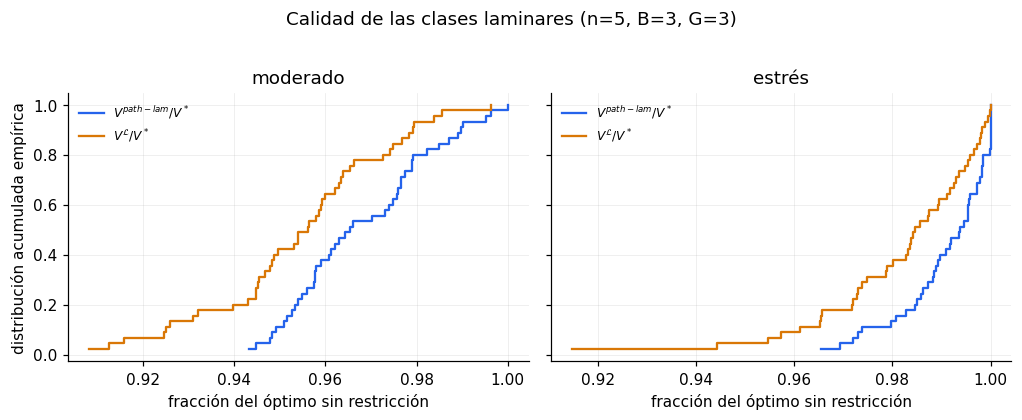

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.7), sharey=True)
for ax, mode in zip(axes, ('moderado', 'estrés')):
    rows = [r for r in quality_rows if r['mode'] == mode]
    for key, label, color in (('path', r'$V^{path-lam}/V^*$', AZUL),
                              ('library', r'$V^{\mathcal{L}}/V^*$', AMBAR)):
        vals = np.sort([r[key] / r['full'] for r in rows])
        ax.step(vals, np.arange(1, len(vals) + 1) / len(vals), where='post',
                label=label, color=color)
    ax.set_xlabel('fracción del óptimo sin restricción')
    ax.set_title(mode)
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel('distribución acumulada empírica')
fig.suptitle(f'Calidad de las clases laminares (n={n_q}, B={B_q}, G={G_q})', y=1.02)
plt.tight_layout(); plt.show()

**Lectura correcta.** Si la razón path-lam vuelve a ser alta, eso
prioriza la búsqueda de un teorema; no lo demuestra. El renglón de estrés y la
instancia peor encontrada son más informativos que un `assert` sobre el mínimo:
sirven como semilla de búsqueda adversaria. El portafolio de árboles mide el
costo adicional de exigir una familia global y compacta.

## 6. Costo de búsqueda: comparación pareada, no conclusión por reloj

Para cada $n$ resolvemos las tres clases sobre las mismas instancias. Medimos:

- estados únicos del memo;
- acciones a las que realmente se aplica Bellman;
- tiempo de pared.

El DP path-laminar poda acciones, pero agrega la familia usada al estado. Por
eso una caída de acciones o de segundos es **evidencia de implementación**, no
una prueba de menor complejidad. En cambio, una biblioteca global fija conserva
el estado original y reduce el número de acciones a $O(n)$; ésa es la ruta más
limpia para un resultado algorítmico.

In [12]:
bench_rows = []
rng = np.random.default_rng(611)
for n in range(4, 8):
    for rep in range(3):
        p, u = draw_instance(rng, n, 'moderado')
        pools = tuple(all_pools(n, min(3, n), include_empty=False))
        lib = candidate_libraries(p, u, min(3, n))['valor inmediato']
        row = {'n': n, 'rep': rep}
        for name, action_set, path in (
                ('full', pools, False), ('path', pools, True), ('fixed', lib, False)):
            stats = {}
            t0 = time.perf_counter()
            value, stats = exact_policy_dp(p, u, 3, action_set,
                                           pathwise_laminar=path, counters=stats)
            row[f'{name}_time'] = time.perf_counter() - t0
            row[f'{name}_states'] = stats['states']
            row[f'{name}_actions'] = stats['bellman_actions']
            row[f'{name}_value'] = value
        assert row['fixed_value'] <= row['path_value'] + 1e-9 <= row['full_value'] + 1e-9
        bench_rows.append(row)

print(' n | estados full/path/fijo | acciones Bellman full/path/fijo | segundos full/path/fijo | welfare path/fijo')
for n in range(4, 8):
    rows = [r for r in bench_rows if r['n'] == n]
    med = lambda key: float(np.median([r[key] for r in rows]))
    print(f'{n:2d} | {med("full_states"):7.0f}/{med("path_states"):7.0f}/{med("fixed_states"):6.0f}'
          f' | {med("full_actions"):9.0f}/{med("path_actions"):9.0f}/{med("fixed_actions"):7.0f}'
          f' | {med("full_time"):5.3f}/{med("path_time"):5.3f}/{med("fixed_time"):5.3f}'
          f' | {med("path_value")/med("full_value"):.3f}/{med("fixed_value")/med("full_value"):.3f}')

 n | estados full/path/fijo | acciones Bellman full/path/fijo | segundos full/path/fijo | welfare path/fijo
 4 |     714/   1933/   216 |      4340/     3504/    504 | 0.007/0.007/0.001 | 0.948/0.907
 5 |    4385/   8241/   556 |     28450/    13740/   1304 | 0.058/0.036/0.003 | 0.983/0.960
 6 |   27668/  32707/  1247 |    146124/    49920/   2760 | 0.408/0.166/0.009 | 0.956/0.936
 7 |  143531/ 116705/  1803 |    607320/   164766/   3652 | 2.537/0.871/0.018 | 0.950/0.891


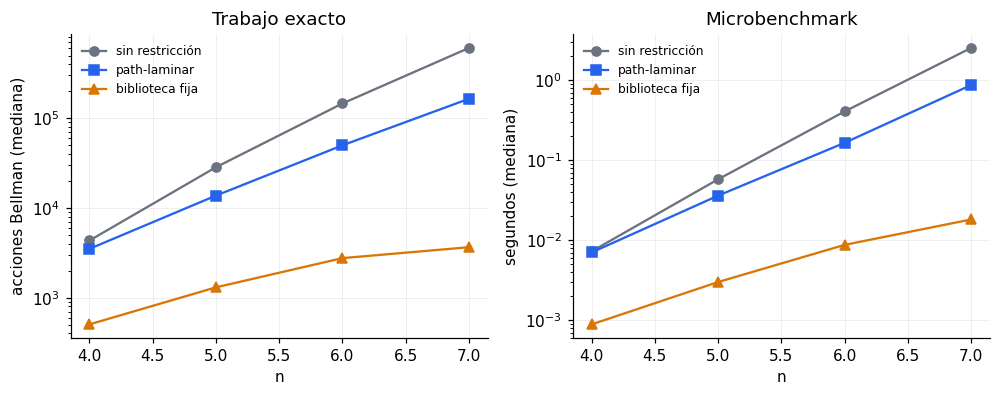

In [13]:
ns_b = list(range(4, 8))
median_by_n = lambda key: [np.median([r[key] for r in bench_rows if r['n'] == n]) for n in ns_b]
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.7))
for key, label, color, marker in (
        ('full_actions', 'sin restricción', GRIS, 'o'),
        ('path_actions', 'path-laminar', AZUL, 's'),
        ('fixed_actions', 'biblioteca fija', AMBAR, '^')):
    axes[0].plot(ns_b, median_by_n(key), marker=marker, color=color, label=label)
for key, label, color, marker in (
        ('full_time', 'sin restricción', GRIS, 'o'),
        ('path_time', 'path-laminar', AZUL, 's'),
        ('fixed_time', 'biblioteca fija', AMBAR, '^')):
    axes[1].plot(ns_b, median_by_n(key), marker=marker, color=color, label=label)
axes[0].set_yscale('log'); axes[1].set_yscale('log')
axes[0].set_xlabel('n'); axes[1].set_xlabel('n')
axes[0].set_ylabel('acciones Bellman (mediana)'); axes[1].set_ylabel('segundos (mediana)')
axes[0].set_title('Trabajo exacto'); axes[1].set_title('Microbenchmark')
axes[0].legend(frameon=False, fontsize=8); axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

## 7. Hacia un “greedy laminar”: control negativo y candidato positivo

Restringir el greedy miope a acciones laminares no añade planeación. El
control adecuado es comparar, dentro de **la misma biblioteca fija**:

1. greedy inmediato;
2. rollout de un paso: para cada acción evalúa recompensa inmediata más la
   continuación del greedy base;
3. óptimo exacto de esa biblioteca.

Con esperanzas exactas, el rollout no puede quedar debajo del greedy: la
acción del propio greedy está entre las candidatas. Esto da una garantía
modesta pero real respecto al baseline, aunque no todavía respecto a $V^*$.

In [14]:
def greedy_and_rollout_values(p, u, B, pools):
    '''Valores exactos del greedy base y su policy improvement de un paso.'''
    n = len(p); weights = profile_weights(p); pools = tuple(pools)

    def branches(remaining, cleared, pool):
        mass = sum(weights[z] for z in remaining)
        out = []
        buckets = {}
        for z in remaining:
            buckets.setdefault(test_result(pool, z), []).append(z)
        for result, profiles in buckets.items():
            bm = sum(weights[z] for z in profiles)
            nc = cleared | pool if result == 0 else cleared
            immediate = (sum(u[i] for i in indices_from_mask(pool & ~cleared, n))
                         if result == 0 else 0.0)
            out.append((bm / mass, frozenset(profiles), nc, immediate))
        return out

    @lru_cache(None)
    def base(k, remaining, cleared):
        if k == B:
            return 0.0
        # El greedy elige sólo por recompensa inmediata esperada.
        scored = []
        for pool in pools:
            br = branches(remaining, cleared, pool)
            immediate = sum(prob * reward for prob, _, _, reward in br)
            scored.append((immediate, pool, br))
        _, chosen, chosen_branches = max(scored, key=lambda x: (x[0], -x[1]))
        return sum(prob * (reward + base(k + 1, nxt, nc))
                   for prob, nxt, nc, reward in chosen_branches)

    @lru_cache(None)
    def rollout(k, remaining, cleared):
        if k == B:
            return 0.0
        scored = []
        for pool in pools:
            br = branches(remaining, cleared, pool)
            q_base = sum(prob * (reward + base(k + 1, nxt, nc))
                         for prob, nxt, nc, reward in br)
            scored.append((q_base, pool, br))
        _, chosen, chosen_branches = max(scored, key=lambda x: (x[0], -x[1]))
        return sum(prob * (reward + rollout(k + 1, nxt, nc))
                   for prob, nxt, nc, reward in chosen_branches)

    root = frozenset(range(1 << n))
    return base(0, root, 0), rollout(0, root, 0)


policy_rows = []
for row in quality_rows[:30] + quality_rows[reps_q:reps_q + 30]:
    lib = candidate_libraries(row['p'], row['u'], G_q)['valor inmediato']
    v_opt_lib = exact_policy_dp(row['p'], row['u'], B_q, lib)[0]
    v_greedy, v_rollout = greedy_and_rollout_values(row['p'], row['u'], B_q, lib)
    assert v_greedy <= v_rollout + 1e-9 <= v_opt_lib + 1e-9
    policy_rows.append((row['mode'], row['full'], v_opt_lib, v_greedy, v_rollout))

print('modo      greedy/V*  rollout/V*  opt(L)/V*  rollout mejora')
for mode in ('moderado', 'estrés'):
    rows = [r for r in policy_rows if r[0] == mode]
    g = np.array([r[3] / r[1] for r in rows])
    ro = np.array([r[4] / r[1] for r in rows])
    ol = np.array([r[2] / r[1] for r in rows])
    print(f'{mode:8s}   {g.mean():.3f}      {ro.mean():.3f}       {ol.mean():.3f}       '
          f'{np.mean(ro > g + 1e-9)*100:4.0f}%')

modo      greedy/V*  rollout/V*  opt(L)/V*  rollout mejora
moderado   0.918      0.938       0.942         83%
estrés     0.958      0.969       0.970         77%


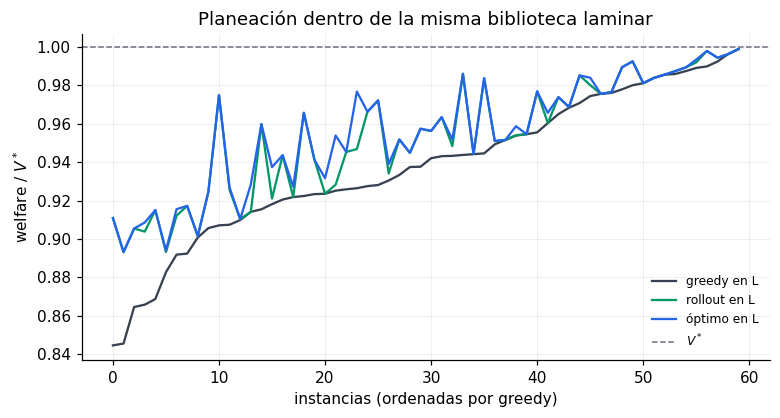

In [15]:
fig, ax = plt.subplots(figsize=(7.2, 3.9))
g = np.array([r[3] / r[1] for r in policy_rows])
ro = np.array([r[4] / r[1] for r in policy_rows])
ol = np.array([r[2] / r[1] for r in policy_rows])
order = np.argsort(g)
x = np.arange(len(order))
ax.plot(x, g[order], color=TINTA, label='greedy en L')
ax.plot(x, ro[order], color=VERDE, label='rollout en L')
ax.plot(x, ol[order], color=AZUL, label='óptimo en L')
ax.axhline(1, color=GRIS, ls='--', lw=1, label=r'$V^*$')
ax.set_xlabel('instancias (ordenadas por greedy)'); ax.set_ylabel('welfare / $V^*$')
ax.set_title('Planeación dentro de la misma biblioteca laminar')
ax.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

# 8. Dirección concreta para la siguiente sesión

## Lo que ya queda claro

1. **MILP:** la ruta lineal correcta es un selector por escenarios. El bloque
   “pool → respuesta → posterior → pool” ya corre y conserva correlaciones.
2. **Laminar algorítmico:** el ejemplo de cadena del notebook 21 se extiende a
   un bosque ramificado. La inferencia exacta se reduce a Poisson-binomiales
   independientes sobre átomos y escala polinomialmente.
3. **Calidad:** $V^{\mathrm{path\text{-}lam}}/V^*$ y
   $V^{\mathcal L}/V^*$ son objetos distintos. Los barridos sólo priorizan
   conjeturas; la instancia peor encontrada debe alimentar la búsqueda
   adversaria.
4. **Facilidad:** una biblioteca fija de tamaño $O(n)$ ofrece la historia más
   limpia. La poda path-laminar puede ayudar en práctica, pero no basta para
   afirmar menor complejidad porque agranda el estado.
5. **Greedy laminar:** “miope + poda” no es la propuesta. El candidato es
   construir una jerarquía y hacer policy improvement/rollout dentro de ella.

## Tres entregables teóricos, en orden

**Lema A — inferencia laminar.** Formalizar la partición por átomos y, dado el
bosque padre-hijos, el algoritmo $O(\sum_A |D_A|c_A)$. Éste es el resultado
más cercano a cerrarse.

**Proposición B — mejora de política.** Probar que, con esperanzas exactas, el
rollout laminar domina al greedy base dentro de la misma $\mathcal L$. Después
medir cuánto cuesta aproximar esas esperanzas con partículas.

**Conjetura/Caza C — aproximación.** Buscar una cota para una jerarquía
construida desde $(p,u,B,G)$ o producir una familia adversaria. No intentar
probar todavía que “todo óptimo laminar es casi óptimo” a partir de promedios.

## Arquitectura experimental sugerida

$$
\text{partículas del posterior}
\xrightarrow{\text{MILP}}\text{pool raíz}
\xrightarrow{R=r}\text{átomos laminares exactos}
\xrightarrow{\text{rollout en }\mathcal L}\text{siguiente pool}.
$$

La siguiente versión debería separar dos archivos reutilizables del cuaderno:
`scenario_milp.py` y `laminar_inference.py`, añadir tests unitarios contra
enumeración y lanzar una búsqueda adversaria con más semillas y varios
$(n,B,G)$.